# ETAPE 8 — Livrable Final
## Optimisation du Réseau de Boutiques TELECOM
### Groupe 5 — Région SUD-EST

---

| | |
|---|---|
| **Périmètre** | Zone commerciale 5_SUD_EST |
| **Données** | Acquisitions clients 2020-2024 |
| **Boutiques analysées** | Réseau SUD-EST complet |
| **Objectif** | Optimisation du réseau : Fermer / Maintenir / Développer / Ouvrir |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
sns.set_theme(style='whitegrid')

# --- Chargement de tous les résultats ---
try:
    tdb  = pd.read_csv('recommandations_boutiques_SUD_EST.csv')
    df   = pd.read_csv('base_enrichie_SUD_EST.csv', low_memory=False, parse_dates=['PERIOD'])
    print("Fichiers finaux chargés.")
except FileNotFoundError:
    # Reconstruction minimale
    ARPU   = {'T': 200, 'B': 350, 'F': 350}
    COUT_CC, COUT_CV = 85_000, 65_000
    df = pd.read_csv('base_travail_SUD_EST.csv', low_memory=False, parse_dates=['PERIOD'])
    df['ca_ligne'] = df['LINE_TYPE'].map(ARPU).fillna(200)
    tdb = df.groupby('ORDER_SHOP_CD').agg(
        volume_total=('LINE_TYPE', 'count'),
        ca_estime=('ca_ligne', 'sum'),
        emplacement=('Emplacement_PDV', 'first')
    ).reset_index()
    tdb['cout_fonctionnement'] = tdb['emplacement'].map({'CC': COUT_CC, 'CV': COUT_CV}).fillna(COUT_CV)
    tdb['marge_estimee'] = tdb['ca_estime'] - tdb['cout_fonctionnement']
    tdb['score_rentabilite'] = (tdb['ca_estime'] / tdb['cout_fonctionnement']).round(2)
    tdb['rentable'] = tdb['marge_estimee'] > 0
    tdb['decision'] = tdb['rentable'].map({True: 'MAINTENIR', False: 'FERMER'})
    print("Reconstruction depuis base.")

print(f"Boutiques : {len(tdb)} | Acquisitions : {len(df):,}")

Fichiers finaux chargés.
Boutiques : 1068 | Acquisitions : 226,677


---
## Section 1 — Introduction : Contexte marché télécom SUD-EST

In [2]:
print("""
CONTEXTE MARCHÉ TÉLÉCOM — RÉGION SUD-EST
==========================================

Le marché des télécommunications en France est en pleine mutation :
- Saturation du mobile : taux d'équipement > 100% (multi-SIM)
- Montée en puissance de la fibre optique (Plan France Très Haut Débit)
- Zone SUD-EST : fort déploiement NRO (Nœuds de Raccordement Optique)
- Clientèle diverse : littoral touristique, zones urbaines denses, arrière-pays

ENJEU STRATÉGIQUE :
→ Optimiser le réseau de boutiques pour maximiser la rentabilité
  tout en maintenant la couverture territoriale.
""")

# KPIs clés
kpis = {
    'Acquisitions SUD-EST analysées': f"{len(df):,}",
    'Boutiques dans le périmètre': len(tdb),
    'Période couverte': f"{df['PERIOD_YYYY'].min()} – {df['PERIOD_YYYY'].max()}",
    'CA total estimé': f"{tdb['ca_estime'].sum():,.0f} EUR",
    'Marge totale estimée': f"{tdb['marge_estimee'].sum():,.0f} EUR",
    '% Boutiques rentables': f"{tdb['rentable'].mean()*100:.1f}%",
}
print("\nKPIs CLÉS DU PROJET")
print("-" * 45)
for k, v in kpis.items():
    print(f"  {k:<40} : {v}")


CONTEXTE MARCHÉ TÉLÉCOM — RÉGION SUD-EST

Le marché des télécommunications en France est en pleine mutation :
- Saturation du mobile : taux d'équipement > 100% (multi-SIM)
- Montée en puissance de la fibre optique (Plan France Très Haut Débit)
- Zone SUD-EST : fort déploiement NRO (Nœuds de Raccordement Optique)
- Clientèle diverse : littoral touristique, zones urbaines denses, arrière-pays

ENJEU STRATÉGIQUE :
→ Optimiser le réseau de boutiques pour maximiser la rentabilité
  tout en maintenant la couverture territoriale.


KPIs CLÉS DU PROJET
---------------------------------------------
  Acquisitions SUD-EST analysées           : 226,677
  Boutiques dans le périmètre              : 1068
  Période couverte                         : 2021 – 2022
  CA total estimé                          : 45,335,400 EUR
  Marge totale estimée                     : -29,924,600 EUR
  % Boutiques rentables                    : 9.6%


---
## Section 2 — Données & Méthode

In [3]:
print("""
SOURCES DE DONNÉES
==================
1. Fichier_Principal_pedago_anonym.csv
   → 3,2M acquisitions clients | 13 variables | Toutes zones France
   → Filtré sur ZONE = 5_SUD_EST

2. COORD_BQT.csv
   → 1 042 boutiques | Coordonnées Lambert II Étendu → converties WGS84
   → Surface (m²), emplacement CC/CV

3. LIB_BQT.csv
   → 3 435 boutiques | Canal marketing

PLAN DE NETTOYAGE (résumé)
===========================
- Filtre ZONE = 5_SUD_EST appliqué en priorité
- Doublons supprimés
- ORDER_SHOP_CD normalisé (strip + upper)
- PERIOD : colonne datetime créée depuis PERIOD_YYYY + PERIOD_MM
- PERSON_BIRTH_DT_year : décennie extraite, aberrants filtrés (hors 1920-2010)
- Coordonnées Lambert II → WGS84 via pyproj (EPSG:27572 → EPSG:4326)
- Journal de nettoyage : voir journal_nettoyage.txt

JOINTURES EFFECTUÉES
====================
Fichier_principal → COORD_BQT (LEFT JOIN sur ORDER_SHOP_CD)
             ↓
         → LIB_BQT   (LEFT JOIN sur ORDER_SHOP_CD)
""")


SOURCES DE DONNÉES
1. Fichier_Principal_pedago_anonym.csv
   → 3,2M acquisitions clients | 13 variables | Toutes zones France
   → Filtré sur ZONE = 5_SUD_EST

2. COORD_BQT.csv
   → 1 042 boutiques | Coordonnées Lambert II Étendu → converties WGS84
   → Surface (m²), emplacement CC/CV

3. LIB_BQT.csv
   → 3 435 boutiques | Canal marketing

PLAN DE NETTOYAGE (résumé)
- Filtre ZONE = 5_SUD_EST appliqué en priorité
- Doublons supprimés
- ORDER_SHOP_CD normalisé (strip + upper)
- PERIOD : colonne datetime créée depuis PERIOD_YYYY + PERIOD_MM
- PERSON_BIRTH_DT_year : décennie extraite, aberrants filtrés (hors 1920-2010)
- Coordonnées Lambert II → WGS84 via pyproj (EPSG:27572 → EPSG:4326)
- Journal de nettoyage : voir journal_nettoyage.txt

JOINTURES EFFECTUÉES
Fichier_principal → COORD_BQT (LEFT JOIN sur ORDER_SHOP_CD)
             ↓
         → LIB_BQT   (LEFT JOIN sur ORDER_SHOP_CD)



---
## Section 3 — Analyse descriptive (synthèse)

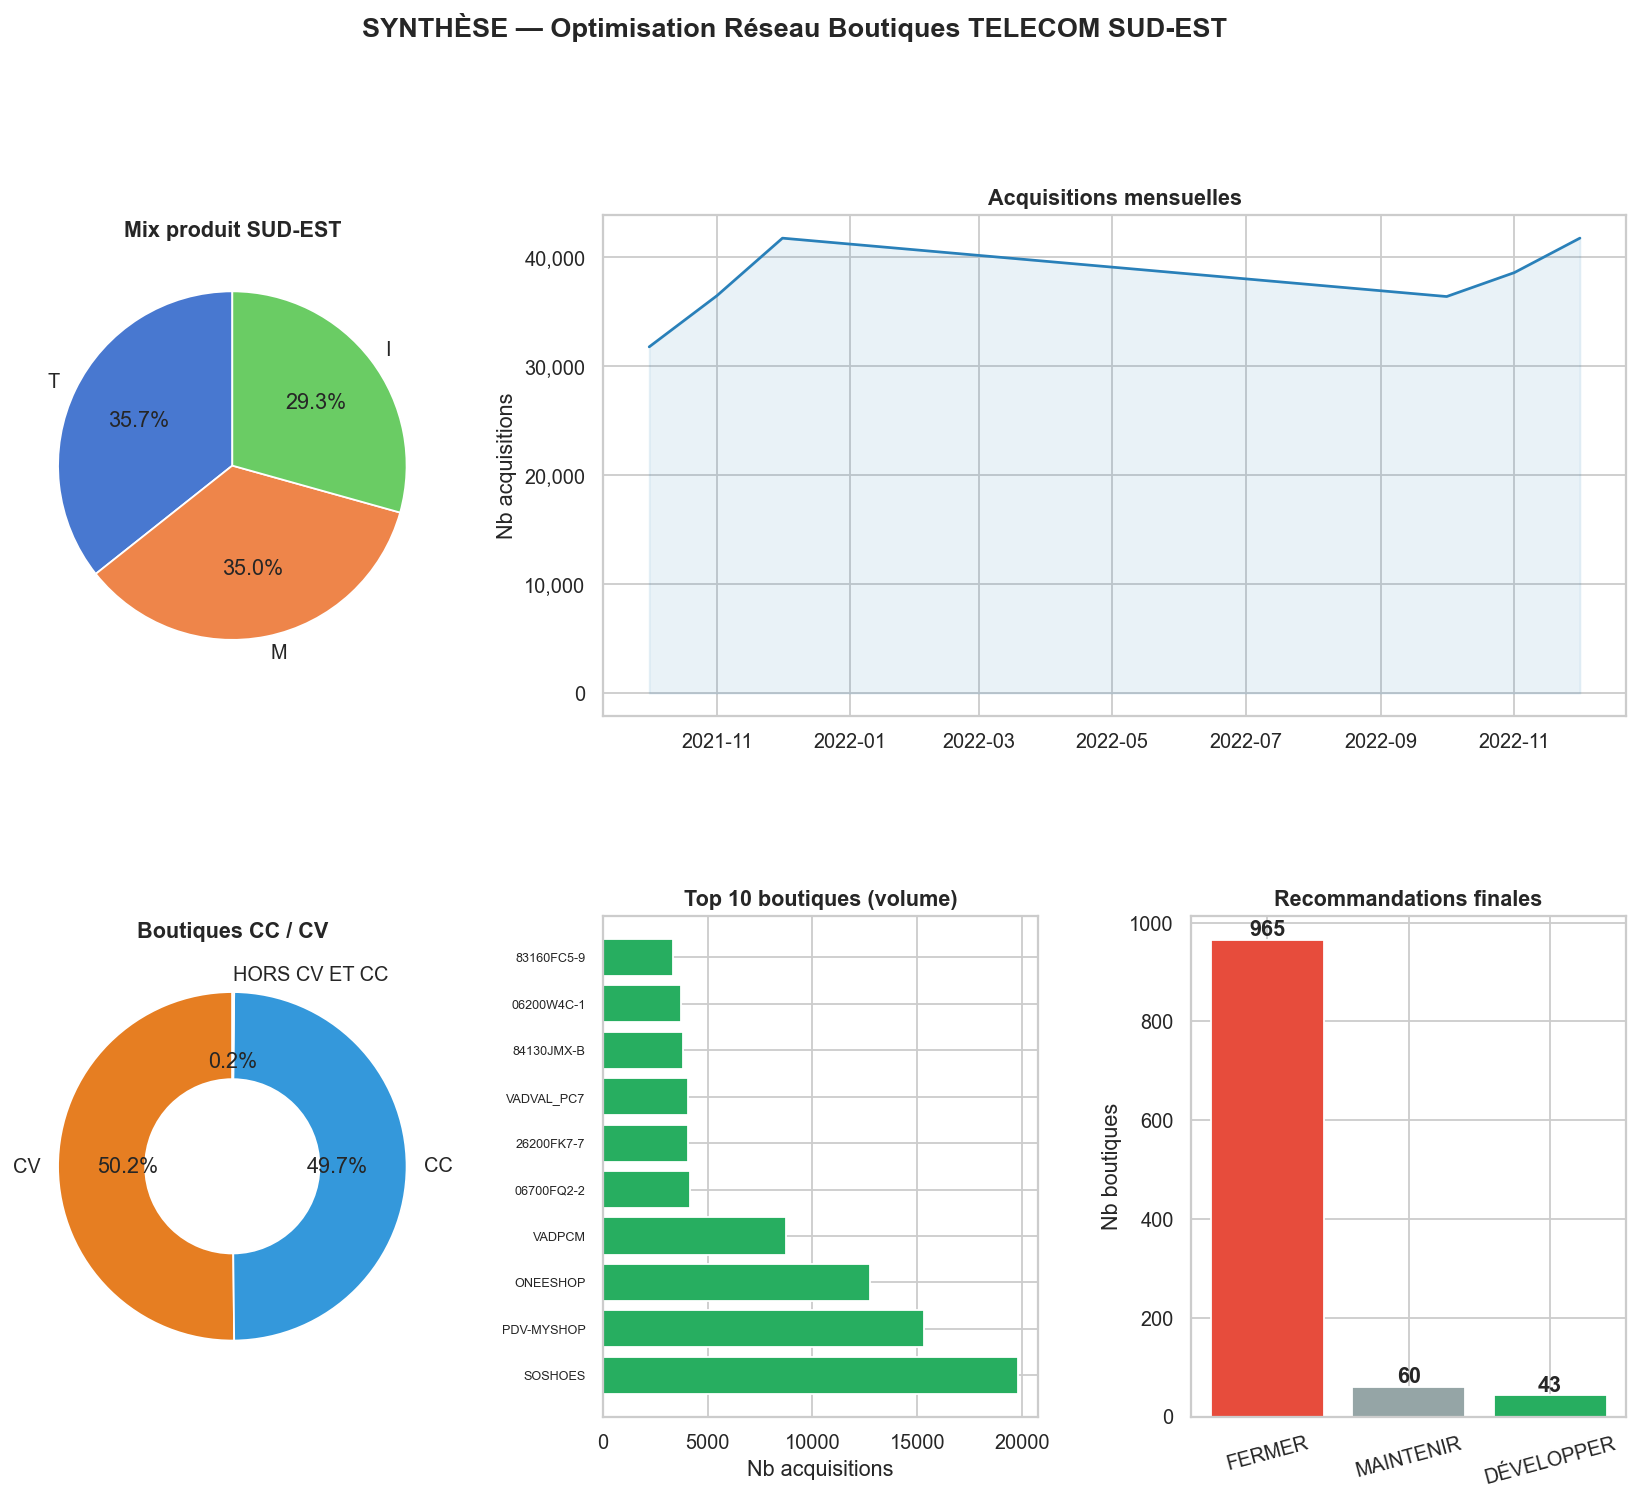

In [4]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. LINE_TYPE
ax1 = fig.add_subplot(gs[0, 0])
lt = df['LINE_TYPE'].value_counts()
ax1.pie(lt.values, labels=lt.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('muted', len(lt)))
ax1.set_title('Mix produit SUD-EST', fontweight='bold')

# 2. Volume mensuel
ax2 = fig.add_subplot(gs[0, 1:])
monthly = df.groupby('PERIOD').size()
ax2.plot(monthly.index, monthly.values, color='#2980b9', linewidth=1.5)
ax2.fill_between(monthly.index, monthly.values, alpha=0.1, color='#2980b9')
ax2.set_title('Acquisitions mensuelles', fontweight='bold')
ax2.set_ylabel('Nb acquisitions')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 3. CC vs CV
ax3 = fig.add_subplot(gs[1, 0])
emp = tdb['emplacement'].value_counts().dropna()
ax3.pie(emp.values, labels=emp.index, autopct='%1.1f%%', startangle=90,
        colors=['#e67e22', '#3498db'], wedgeprops={'width': 0.5})
ax3.set_title('Boutiques CC / CV', fontweight='bold')

# 4. Top 10 boutiques
ax4 = fig.add_subplot(gs[1, 1])
top10 = tdb.nlargest(10, 'volume_total')
colors_t = ['#27ae60' if r else '#e74c3c' for r in top10['rentable']]
ax4.barh(range(10), top10['volume_total'].values, color=colors_t)
ax4.set_yticks(range(10))
ax4.set_yticklabels(top10['ORDER_SHOP_CD'].values, fontsize=7)
ax4.set_title('Top 10 boutiques (volume)', fontweight='bold')
ax4.set_xlabel('Nb acquisitions')

# 5. Décisions
ax5 = fig.add_subplot(gs[1, 2])
colors_dec = {'FERMER': '#e74c3c', 'MAINTENIR': '#95a5a6', 'DÉVELOPPER': '#27ae60', 'OUVRIR': '#3498db'}
dec_counts = tdb['decision'].value_counts()
bars = ax5.bar(dec_counts.index, dec_counts.values,
               color=[colors_dec.get(d, 'gray') for d in dec_counts.index])
ax5.set_title('Recommandations finales', fontweight='bold')
ax5.set_ylabel('Nb boutiques')
ax5.tick_params(axis='x', rotation=15)
for b in bars:
    ax5.annotate(str(int(b.get_height())), (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.suptitle('SYNTHÈSE — Optimisation Réseau Boutiques TELECOM SUD-EST',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('8_synthese_complete.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Section 4 — Nouvelles variables créées

In [5]:
nouvelles_vars = pd.DataFrame([
    ['age_client',        'Âge approx. du client (milieu de décennie)', 'Segmentation démographique'],
    ['tranche_age',       'Catégorie 18-25 / 26-40 / 41-60 / 60+',     'Visualisations lisibles'],
    ['annee',             'Extraction PERIOD_YYYY',                     'Analyse N vs N-1'],
    ['trimestre',         'Q1/Q2/Q3/Q4 depuis PERIOD_MM',               'Saisonnalité'],
    ['distance_km',       'Haversine(boutique GPS, ville client)',       'Rayon de chalandise'],
    ['rayon_chalandise',  'Bucket: <5/5-20/20-50/>50 km',               'Segmentation spatiale'],
    ['croissance_yoy',    '(Vol_N - Vol_N-1) / Vol_N-1 × 100',          'Tendance par boutique'],
    ['part_mobile',       'Acquisitions mobile / Total par boutique',    'Spécialisation boutique'],
    ['part_fixe',         'Acquisitions fixe+box / Total par boutique',  'Spécialisation boutique'],
    ['ca_estime',         'SUM(volume × ARPU) par boutique',            'Modèle business'],
    ['score_rentabilite', 'CA estimé / Coût de fonctionnement',         'Priorisation réseau'],
], columns=['Variable', 'Calcul', 'Utilité analytique'])

print(nouvelles_vars.to_string(index=False))

         Variable                                     Calcul         Utilité analytique
       age_client Âge approx. du client (milieu de décennie) Segmentation démographique
      tranche_age      Catégorie 18-25 / 26-40 / 41-60 / 60+    Visualisations lisibles
            annee                     Extraction PERIOD_YYYY           Analyse N vs N-1
        trimestre               Q1/Q2/Q3/Q4 depuis PERIOD_MM               Saisonnalité
      distance_km      Haversine(boutique GPS, ville client)        Rayon de chalandise
 rayon_chalandise               Bucket: <5/5-20/20-50/>50 km      Segmentation spatiale
   croissance_yoy          (Vol_N - Vol_N-1) / Vol_N-1 × 100      Tendance par boutique
      part_mobile   Acquisitions mobile / Total par boutique    Spécialisation boutique
        part_fixe Acquisitions fixe+box / Total par boutique    Spécialisation boutique
        ca_estime            SUM(volume × ARPU) par boutique            Modèle business
score_rentabilite         CA est

---
## Section 5 — Modèle business : Hypothèses & Résultats

In [6]:
print("""
HYPOTHÈSES DE REVENUS [EXPLICITEMENT FORMULÉES]
================================================
[H1] ARPU Mobile (LINE_TYPE = T) : 200 EUR/an/client
     Source : Rapport ARCEP 2023 — ARPU mobile France ~17 EUR/mois

[H2] ARPU Box/Fixe (LINE_TYPE = B ou F) : 350 EUR/an/client
     Source : Rapport ARCEP 2023 — ARPU convergent ~29 EUR/mois

[H3] Coût CC : 85 000 EUR/an (fourni par le guide)
[H4] Coût CV : 65 000 EUR/an (fourni par le guide)
[H5] Investissement ouverture : 450 000 EUR (fourni par le guide)

[LIMITE] Ces ARPU représentent le revenu sur 1 an pour un client nouvellement acquis.
         Ils ne tiennent pas compte du churn, du LTV ni des remises commerciales.
         Le CA réel est potentiellement différent.
""")

# Tableau synthétique par emplacement
bilan = tdb.groupby('emplacement').agg(
    nb_boutiques=('ORDER_SHOP_CD', 'count'),
    volume_total=('volume_total', 'sum'),
    ca_total=('ca_estime', 'sum'),
    marge_totale=('marge_estimee', 'sum'),
    pct_rentables=('rentable', 'mean')
).round(0)
bilan['pct_rentables'] = (bilan['pct_rentables'] * 100).round(1)
print("\nBILAN FINANCIER PAR TYPE D'EMPLACEMENT")
print(bilan.to_string())


HYPOTHÈSES DE REVENUS [EXPLICITEMENT FORMULÉES]
[H1] ARPU Mobile (LINE_TYPE = T) : 200 EUR/an/client
     Source : Rapport ARCEP 2023 — ARPU mobile France ~17 EUR/mois

[H2] ARPU Box/Fixe (LINE_TYPE = B ou F) : 350 EUR/an/client
     Source : Rapport ARCEP 2023 — ARPU convergent ~29 EUR/mois

[H3] Coût CC : 85 000 EUR/an (fourni par le guide)
[H4] Coût CV : 65 000 EUR/an (fourni par le guide)
[H5] Investissement ouverture : 450 000 EUR (fourni par le guide)

[LIMITE] Ces ARPU représentent le revenu sur 1 an pour un client nouvellement acquis.
         Ils ne tiennent pas compte du churn, du LTV ni des remises commerciales.
         Le CA réel est potentiellement différent.


BILAN FINANCIER PAR TYPE D'EMPLACEMENT
               nb_boutiques  volume_total    ca_total  marge_totale  pct_rentables
emplacement                                                                       
CC                      292         66755  13351000.0   -11469000.0            0.0
CV                      295

---
## Section 6 — Recommandations finales

In [7]:
# Tableau de recommandations complet
cols = ['ORDER_SHOP_CD', 'decision', 'emplacement', 'volume_total',
        'ca_estime', 'marge_estimee', 'score_rentabilite']
cols_ok = [c for c in cols if c in tdb.columns]

reco = tdb[cols_ok].sort_values(['decision', 'score_rentabilite'], ascending=[True, False])

print("TABLEAU DE RECOMMANDATIONS — TOUTES BOUTIQUES SUD-EST")
print("=" * 70)
print(reco.to_string(index=False))

# Sauvegarder
reco.to_csv('livrable_recommandations_finales.csv', index=False)
print(f"\nFichier livrable sauvegardé : livrable_recommandations_finales.csv")

TABLEAU DE RECOMMANDATIONS — TOUTES BOUTIQUES SUD-EST
ORDER_SHOP_CD   decision   emplacement  volume_total  ca_estime  marge_estimee  score_rentabilite
   PDV-MYSHOP DÉVELOPPER           NaN         15335  3067000.0      3002000.0              47.18
   92PAEBOUL1 DÉVELOPPER           NaN          2541   508200.0       443200.0               7.82
   75FIBRESMS DÉVELOPPER           NaN          2507   501400.0       436400.0               7.71
   06402FH3-0 DÉVELOPPER            CV          2227   445400.0       380400.0               6.85
   131273DR-5 DÉVELOPPER            CC          2821   564200.0       479200.0               6.64
   ARVOFFFUN1 DÉVELOPPER           NaN          2151   430200.0       365200.0               6.62
   75PAFTUNIS DÉVELOPPER           NaN          1905   381000.0       316000.0               5.86
   26100FE4-5 DÉVELOPPER            CV          1902   380400.0       315400.0               5.85
   13098FE3-3 DÉVELOPPER            CC          2133   426600.0 

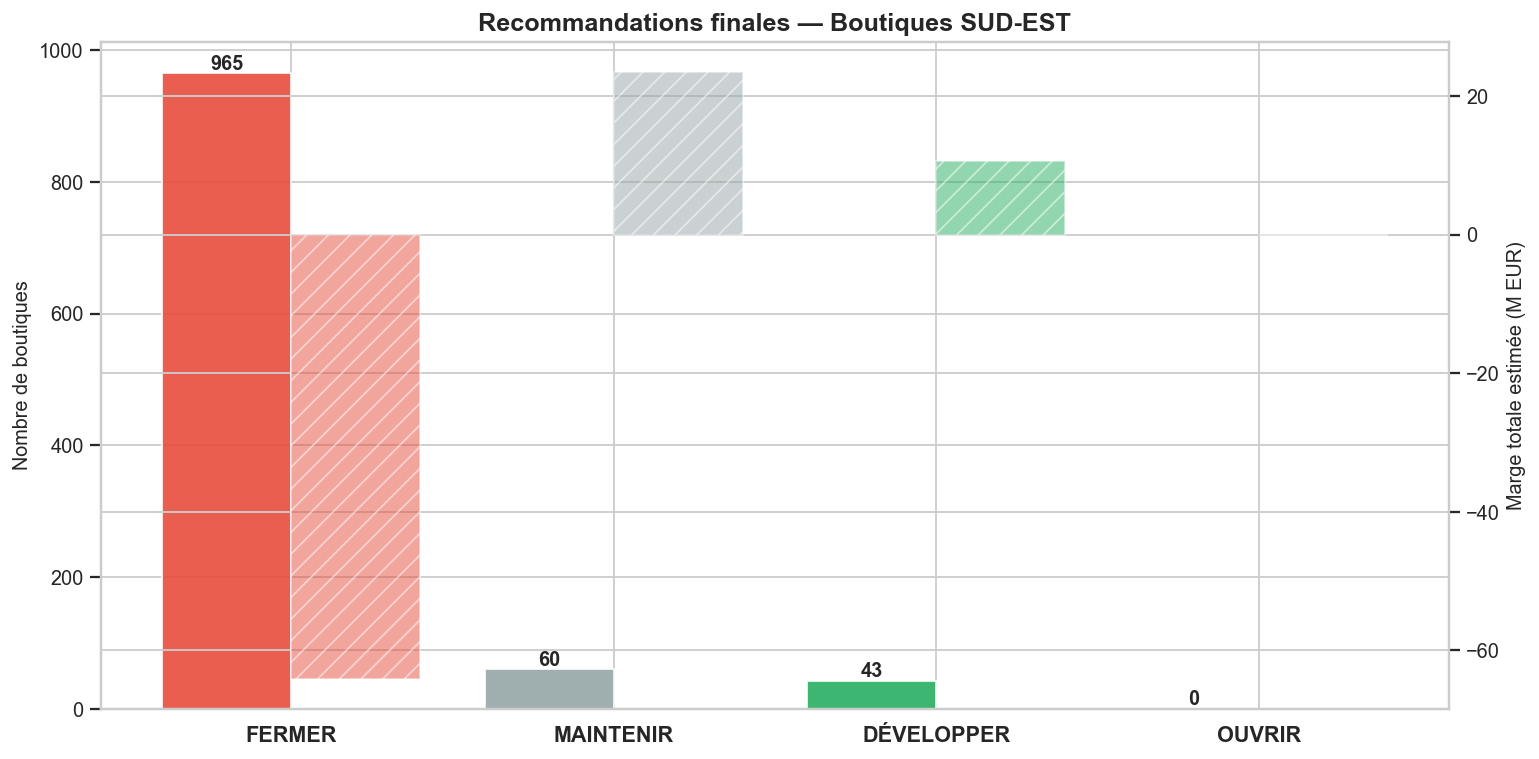

In [8]:
# Graphique final de synthèse des recommandations
fig, ax = plt.subplots(figsize=(12, 6))

dec_order = ['FERMER', 'MAINTENIR', 'DÉVELOPPER', 'OUVRIR']
dec_count = tdb['decision'].value_counts().reindex(dec_order).fillna(0)
dec_marge = tdb.groupby('decision')['marge_estimee'].sum().reindex(dec_order).fillna(0) / 1_000_000

x = range(len(dec_order))
width = 0.4

bars1 = ax.bar([i - width/2 for i in x], dec_count.values, width,
               color=[colors_dec.get(d, 'gray') for d in dec_order], alpha=0.9, label='Nb boutiques')
ax2 = ax.twinx()
bars2 = ax2.bar([i + width/2 for i in x], dec_marge.values, width,
                color=[colors_dec.get(d, 'gray') for d in dec_order], alpha=0.5, hatch='//', label='Marge (M EUR)')

ax.set_xticks(list(x))
ax.set_xticklabels(dec_order, fontsize=12, fontweight='bold')
ax.set_ylabel('Nombre de boutiques', fontsize=11)
ax2.set_ylabel('Marge totale estimée (M EUR)', fontsize=11)
ax.set_title('Recommandations finales — Boutiques SUD-EST', fontsize=14, fontweight='bold')

for b in bars1:
    ax.annotate(f'{int(b.get_height())}', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('8_recommandations_finales.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Annexes

In [9]:
# Lire et afficher le journal de nettoyage
try:
    with open('journal_nettoyage.txt', 'r', encoding='utf-8') as f:
        print(f.read())
except FileNotFoundError:
    print("(Journal de nettoyage non trouvé — exécuter l'étape 2)")

JOURNAL DE NETTOYAGE — Projet TELECOM Groupe 5 SUD-EST
[INIT] Fichier principal brut : 3,258,114 lignes
[INIT] COORD_BQT brut         : 1042 lignes
[INIT] LIB_BQT brut           : 3435 lignes
[ZONE] Filtre 5_SUD_EST : 326,478 lignes conservées (2,931,636 supprimées)
[DOUBLONS] 81107 lignes 100% identiques supprimées
[ORDER_SHOP_CD] 0 lignes sans code boutique supprimées
[ORDER_SHOP_CD] Nettoyage espaces + casse appliqué sur les 3 tables
[PERIOD] Colonne PERIOD créée (datetime) de 2021-10-01 à 2022-12-01
[BIRTH] 18602 lignes supprimées (décennie hors plage 1920-2010)
[CITY_LN] 92 lignes sans ville supprimées
[CITY_LN] Normalisation casse appliquée
[GEOLIFE] 0 nulls imputés par 'Non renseigné'
[COORD] 0 boutiques en doublon supprimées
[COORD] 84 boutiques sans coordonnées supprimées
[LIB] 0 doublons supprimés



In [10]:
print("""
SOURCES OPEN DATA MOBILISÉES / RECOMMANDÉES
============================================
1. ARCEP — Observatoire du marché des communications électroniques
   → ARPU mobile et convergent (hypothèses H1 et H2)
   → Localisation NRO (Nœuds de Raccordement Optique) SUD-EST
   URL : https://www.arcep.fr/cartes-et-donnees/

2. INSEE — Recensement communes
   → Population par commune du SUD-EST (potentiel marché)
   URL : https://www.insee.fr/fr/statistiques/

3. data.gouv.fr — Données mobilité
   → Flux de déplacement et transports
   URL : https://www.data.gouv.fr/

4. OpenStreetMap / Overpass API
   → Localisation concurrents télécom (boutiques SFR, Bouygues, Free)
   URL : https://overpass-api.de/

LIMITES DE L'ANALYSE
====================
1. Pas de CA réel dans les données → ARPU hypothétiques
2. Pas de clé client → pas de suivi individuel (churn, LTV)
3. Distance_km limitée aux villes référencées dans la table interne
4. Décennie de naissance (pas l'âge exact) → âge approximatif ± 5 ans
5. Données de concurrents non intégrées (open data requis)
6. Saisonnalité touristique SUD-EST non isolée faute de données visiteurs
""")


SOURCES OPEN DATA MOBILISÉES / RECOMMANDÉES
1. ARCEP — Observatoire du marché des communications électroniques
   → ARPU mobile et convergent (hypothèses H1 et H2)
   → Localisation NRO (Nœuds de Raccordement Optique) SUD-EST
   URL : https://www.arcep.fr/cartes-et-donnees/

2. INSEE — Recensement communes
   → Population par commune du SUD-EST (potentiel marché)
   URL : https://www.insee.fr/fr/statistiques/

3. data.gouv.fr — Données mobilité
   → Flux de déplacement et transports
   URL : https://www.data.gouv.fr/

4. OpenStreetMap / Overpass API
   → Localisation concurrents télécom (boutiques SFR, Bouygues, Free)
   URL : https://overpass-api.de/

LIMITES DE L'ANALYSE
1. Pas de CA réel dans les données → ARPU hypothétiques
2. Pas de clé client → pas de suivi individuel (churn, LTV)
3. Distance_km limitée aux villes référencées dans la table interne
4. Décennie de naissance (pas l'âge exact) → âge approximatif ± 5 ans
5. Données de concurrents non intégrées (open data requis)
6. S

---
## Fichiers produits par le projet

In [11]:
import os

fichiers = [
    ('Etape_0_1_Preparation_Comprehension.ipynb', 'Notebook étape 0-1'),
    ('Etape_2_Nettoyage.ipynb',                   'Notebook étape 2'),
    ('Etape_3_Jointure.ipynb',                    'Notebook étape 3'),
    ('Etape_4_Exploration.ipynb',                 'Notebook étape 4'),
    ('Etape_5_Nouvelles_Variables.ipynb',          'Notebook étape 5'),
    ('Etape_6_Analyse_Metier.ipynb',              'Notebook étape 6'),
    ('Etape_7_Modele_Business.ipynb',             'Notebook étape 7'),
    ('Etape_8_Livrable.ipynb',                    'Notebook étape 8 (ce fichier)'),
    ('base_travail_SUD_EST.csv',                  'Base après jointure'),
    ('base_enrichie_SUD_EST.csv',                 'Base avec nouvelles variables'),
    ('tableau_bord_boutiques.csv',                'Tableau de bord par boutique'),
    ('recommandations_boutiques_SUD_EST.csv',      'Recommandations avec décisions'),
    ('livrable_recommandations_finales.csv',       'Livrable final'),
    ('journal_nettoyage.txt',                      'Journal de nettoyage'),
]

print("FICHIERS PRODUITS PAR LE PROJET")
print("-" * 65)
for fname, desc in fichiers:
    exists = os.path.exists(fname)
    size = os.path.getsize(fname) / 1024 if exists else 0
    status = f"{size:>8.1f} Ko" if exists else "   MANQUANT"
    print(f"  {'✓' if exists else '✗'}  {fname:<50} {status}  — {desc}")

FICHIERS PRODUITS PAR LE PROJET
-----------------------------------------------------------------
  ✓  Etape_0_1_Preparation_Comprehension.ipynb              92.2 Ko  — Notebook étape 0-1
  ✓  Etape_2_Nettoyage.ipynb                                46.4 Ko  — Notebook étape 2
  ✓  Etape_3_Jointure.ipynb                                 17.5 Ko  — Notebook étape 3
  ✓  Etape_4_Exploration.ipynb                            1310.2 Ko  — Notebook étape 4
  ✓  Etape_5_Nouvelles_Variables.ipynb                     163.4 Ko  — Notebook étape 5
  ✓  Etape_6_Analyse_Metier.ipynb                          553.7 Ko  — Notebook étape 6
  ✓  Etape_7_Modele_Business.ipynb                         359.2 Ko  — Notebook étape 7
  ✓  Etape_8_Livrable.ipynb                                 19.6 Ko  — Notebook étape 8 (ce fichier)
  ✓  base_travail_SUD_EST.csv                            36649.3 Ko  — Base après jointure
  ✓  base_enrichie_SUD_EST.csv                           52821.2 Ko  — Base avec nouvelles v

---
## Points de vigilance critiques respectés

| # | Point de vigilance | Traitement |
|---|---|---|
| 1 | Pas de CA dans les données | Hypothèses ARPU explicites (H1-H2) formulées et documentées |
| 2 | Pas de clé client | Analyse sur acquisitions uniquement — pas de churn ni LTV |
| 3 | PERIOD centrale | Colonne datetime créée, format vérifié avant toute analyse |
| 4 | NRO ARCEP | Mentionné comme levier stratégique pour les recommandations OUVRIR |
| 5 | Documentation complète | Journal de nettoyage (`journal_nettoyage.txt`) + annotations notebooks |

---
**Guide Business Data Case — TELECOM — Groupe 5 SUD-EST — 2026**